In [93]:

import pandas as pd

data_frame = pd.read_csv("/home/unknown/Projects/Youcode/06_deliveryETA/data/food-delivery-6ab250c2ce296539694086.csv")

data_frame.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [94]:
df_clean = data_frame.copy()
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  str    
 1   Delivery_person_ID           45593 non-null  str    
 2   Delivery_person_Age          45593 non-null  str    
 3   Delivery_person_Ratings      45593 non-null  str    
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  str    
 9   Time_Orderd                  45593 non-null  str    
 10  Time_Order_picked            45593 non-null  str    
 11  Weatherconditions            45593 non-null  str    
 12  Road_traffic_density         45593 non-null  str    
 13  Vehicle_condition          

In [95]:
import numpy as np 

if 'ID' or 'Delivery_person_ID' in df_clean.columns:
    df_clean = df_clean.drop(columns=['ID', 'Delivery_person_ID'])

print(df_clean.columns)
# df_clean['Weatherconditions']

Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)'],
      dtype='str')


In [96]:
 

string_cols = df_clean.select_dtypes(include=['str']).columns

# print(string_cols)



In [97]:
for col in string_cols:
    df_clean[col] = df_clean[col].astype(str).str.strip()
    df_clean[col] = df_clean[col].replace(["nan","null",''], np.nan, regex= False)

print(df_clean.columns)
if 'Weatherconditions' in df_clean.columns:
    df_clean['Weatherconditions'] = df_clean['Weatherconditions'].str.replace('conditions', '')
# print(df_clean['Weatherconditions'])



Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)'],
      dtype='str')


In [98]:
# print(df_clean[['Delivery_person_Age', 'Delivery_person_Ratings', 'multiple_deliveries']])
num_cols_to_convert = ['Delivery_person_Age', 'Delivery_person_Ratings', 'multiple_deliveries']
# print(df_clean[['Delivery_person_Age', 'Delivery_person_Ratings', 'multiple_deliveries']])
for col in num_cols_to_convert:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype(float)

# df_clean[['Delivery_person_Age', 'Delivery_person_Ratings', 'multiple_deliveries']].dtypes

if 'Order_Date' in df_clean.columns:
    df_clean['Order_Date'] = pd.to_datetime(df_clean['Order_Date'],format='%d-%m-%y', errors='coerce')
    



In [99]:
df_clean[['Delivery_person_Age', 'Delivery_person_Ratings', 'multiple_deliveries', 'Order_Date']].dtypes

Delivery_person_Age              float64
Delivery_person_Ratings          float64
multiple_deliveries              float64
Order_Date                 datetime64[s]
dtype: object

In [100]:
df_clean['Time_Orderd'] = pd.to_timedelta(df_clean['Time_Orderd'],errors="coerce")
df_clean['Time_Order_picked'] = pd.to_timedelta(df_clean['Time_Order_picked'], errors="coerce")

# print(df_clean[['Time_Orderd', 'Time_Order_picked']].dtypes)

df_clean['Preparation_Time_min'] = (df_clean['Time_Order_picked'] - df_clean['Time_Orderd']).dt.total_seconds() / 60
df_clean['Preparation_Time_min'] = df_clean['Preparation_Time_min'].apply(lambda x: x + 1440 if x < 0 else x)
print(f"conversion reussie nombre de valeur manquant cree : ",df_clean['Preparation_Time_min'].isnull().sum())


conversion reussie nombre de valeur manquant cree :  1731


In [101]:
# time_cols = [columns for olumns in df_clean.columns if 'Time_']

print("missing values per colums")
df_clean.isnull().sum()

missing values per colums


Delivery_person_Age             1854
Delivery_person_Ratings         1908
Restaurant_latitude                0
Restaurant_longitude               0
Delivery_location_latitude         0
Delivery_location_longitude        0
Order_Date                     45593
Time_Orderd                     1731
Time_Order_picked                  0
Weatherconditions                  0
Road_traffic_density               0
Vehicle_condition                  0
Type_of_order                      0
Type_of_vehicle                    0
multiple_deliveries              993
Festival                           0
City                               0
Time_taken(min)                    0
Preparation_Time_min            1731
dtype: int64

In [ ]:
# print(df_clean.dtypes)
print(df_clean[
    ['Delivery_person_Age',
     'Delivery_person_Ratings',
     'Preparation_Time_min',
     'multiple_deliveries']
].isna().sum())

Delivery_person_Age                    float64
Delivery_person_Ratings                float64
Restaurant_latitude                    float64
Restaurant_longitude                   float64
Delivery_location_latitude             float64
Delivery_location_longitude            float64
Order_Date                       datetime64[s]
Time_Orderd                    timedelta64[us]
Time_Order_picked              timedelta64[us]
Weatherconditions                          str
Road_traffic_density                       str
Vehicle_condition                        int64
Type_of_order                              str
Type_of_vehicle                            str
multiple_deliveries                    float64
Festival                                   str
City                                       str
Time_taken(min)                            str
Preparation_Time_min                   float64
dtype: object
Delivery_person_Age        1854
Delivery_person_Ratings    1908
Preparation_Time_min       17

In [103]:
print("--valeur manwuant avan imputatio --")
missing_before=df_clean.isnull().sum()
print(missing_before[missing_before > 0])

df_clean.head(60)


    

--valeur manwuant avan imputatio --
Delivery_person_Age         1854
Delivery_person_Ratings     1908
Order_Date                 45593
Time_Orderd                 1731
multiple_deliveries          993
Preparation_Time_min        1731
dtype: int64


,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),Preparation_Time_min
0,37.0,4.9,22.745049,75.892471,22.765049,75.912471,NaT,0 days 11:30:00,0 days 11:45:00,Sunny,High,2,Snack,motorcycle,0.0,No,Urban,(min) 24,15.0
1,34.0,4.5,12.913041,77.683237,13.043041,77.813237,NaT,0 days 19:45:00,0 days 19:50:00,Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,(min) 33,5.0
2,23.0,4.4,12.914264,77.678400,12.924264,77.688400,NaT,0 days 08:30:00,0 days 08:45:00,Sandstorms,Low,0,Drinks,motorcycle,1.0,No,Urban,(min) 26,15.0
3,38.0,4.7,11.003669,76.976494,11.053669,77.026494,NaT,0 days 18:00:00,0 days 18:10:00,Sunny,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,(min) 21,10.0
4,32.0,4.6,12.972793,80.249982,13.012793,80.289982,NaT,0 days 13:30:00,0 days 13:45:00,Cloudy,High,1,Snack,scooter,1.0,No,Metropolitian,(min) 30,15.0
5,22.0,4.8,17.431668,78.408321,17.461668,78.438321,NaT,0 days 21:20:00,0 days 21:30:00,Cloudy,Jam,0,Buffet,motorcycle,1.0,No,Urban,(min) 26,10.0
6,33.0,4.7,23.369746,85.339820,23.479746,85.449820,NaT,0 days 19:15:00,0 days 19:30:00,Fog,Jam,1,Meal,scooter,1.0,No,Metropolitian,(min) 40,15.0
7,35.0,4.6,12.352058,76.606650,12.482058,76.736650,NaT,0 days 17:25:00,0 days 17:30:00,Cloudy,Medium,2,Meal,motorcycle,1.0,No,Metropolitian,(min) 32,5.0
8,22.0,4.8,17.433809,78.386744,17.563809,78.516744,NaT,0 days 20:55:00,0 days 21:05:00,Stormy,Jam,0,Buffet,motorcycle,1.0,No,Metropolitian,(min) 34,10.0
9,36.0,4.2,30.327968,78.046106,30.397968,78.116106,NaT,0 days 21:55:00,0 days 22:10:00,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,(min) 46,15.0


In [104]:
df_clean.to_csv("clean_new_dataset.csv")
num_duplicates = df_clean.duplicated().sum()
print(f"numner of duplicates rows:{num_duplicates}") 

df_clean.describe()

numner of duplicates rows:0


,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Vehicle_condition,multiple_deliveries,Preparation_Time_min
count,43739.000000,43685.000000,45593.000000,45593.000000,45593.000000,45593.000000,0,43862,45593,45593.000000,44600.000000,43862.000000
mean,29.567137,4.633780,17.017729,70.231332,17.465186,70.845702,NaT,0 days 17:54:59.856367,0 days 17:37:17.389511,1.023359,0.744664,9.989399
min,15.000000,1.000000,-30.905562,-88.366217,0.010000,0.010000,NaT,0 days 00:00:00,0 days 00:00:00,0.000000,0.000000,5.000000
25%,25.000000,4.500000,12.933284,73.170000,12.988453,73.280000,NaT,0 days 15:25:00,0 days 14:35:00,0.000000,0.000000,5.000000
50%,30.000000,4.700000,18.546947,75.898497,18.633934,76.002574,NaT,0 days 19:15:00,0 days 19:10:00,1.000000,1.000000,10.000000
75%,35.000000,4.900000,22.728163,78.044095,22.785049,78.107044,NaT,0 days 21:35:00,0 days 21:35:00,2.000000,1.000000,15.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,NaT,0 days 23:55:00,0 days 23:55:00,3.000000,3.000000,15.000000
std,5.815155,0.334716,8.185109,22.883647,7.335122,21.118812,NaN,0 days 04:50:25.659947,0 days 05:21:57.706870,0.839065,0.572473,4.087516


In [ ]:
df_clean = df_clean[df_clean['Delivery_Time_min'] <= 120]
# df_clean.describe()

df_clean.to_csv('../data/df_clean.csv', index=False)
79
print("cest ca etap 1 ")
print(f"Nombre de commande expoitable conserve : {len(df_clean)}")

KeyError: 'Delivery_Time_min'

In [ ]:
df = pd.read_csv("../data/df_clean.csv")

# print(df.head)
df.columns
df['Net_transit_time'] = df['Delivery_Time_min'] - df['Preparation_Time_min']

df['Speed_km_per_hour'] = (df['Distance_km'] / ((df['Net_transit_time'] + 0.1) / 60))

print("new columns created sucefully")
# print(df.columns)
print(df[['Delivery_Time_min', 'Preparation_Time_min', 'Net_transit_time', 'Speed_km_per_']])


new columns created sucefully
     Delivery_Time_min  Preparation_Time_min  Net_transit_time  \
0                   43                    12                31   
1                   84                    20                64   
2                   59                    28                31   
3                   37                     5                32   
4                   68                    16                52   
..                 ...                   ...               ...   
989                 54                    13                41   
990                 71                     8                63   
991                 81                    26                55   
992                 55                     8                47   
993                 58                    24                34   

     Speed_km_per_hour  
0             0.004250  
1             0.004269  
2             0.005102  
3             0.003863  
4             0.006088  
..                 ...  
98

Index(['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='str')


<Axes: xlabel='Delivery_Time_min', ylabel='Count'>

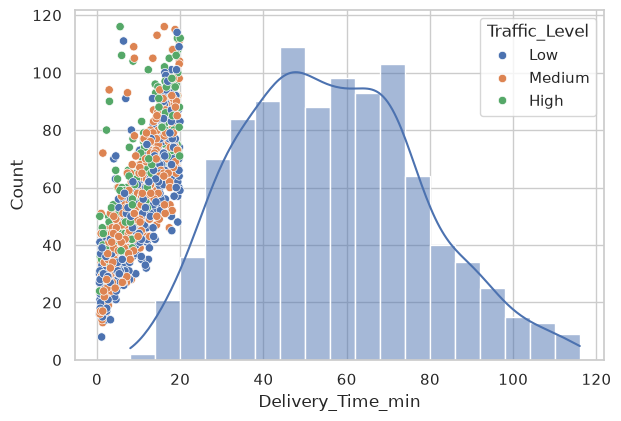

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns 
79
sns.set_theme(style='whitegrid')

plt.figure(figsize=(15,10))

plt.subplot(2,2,1)
sns.histplot(df['Delivery_Time_min'], kde=True)
# print(df_clean.columns)
sns.scatterplot(x='Distance_km', y='Delivery_Time_min', hue='Traffic_Level', data=df)

In [ ]:
df_clean.isnull()